In [19]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

# from pandas import read_csv
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from keras.layers import LSTM, Flatten

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

#from keras.callbacks import EarlyStopping
from keras.layers import ConvLSTM2D


import ipympl 
%matplotlib ipympl

file_path = 'Cinemark_data_for_all_algorithms.csv'

df = pd.read_csv(file_path)
df.set_index('Date_Time', inplace=True)
df = df.drop('Unnamed: 0', axis = 1)
display(df)

,Facility_Demand_Rate_kW,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD01_Zone_Mean_Air_Temperature,AUD01_HTG_SETPT,AUD01_CLG_SETPT,AUD02_Zone_Mean_Air_Temperature,AUD02_HTG_SETPT,AUD02_CLG_SETPT,AUD03_Zone_Mean_Air_Temperature,AUD03_HTG_SETPT,...,PROJC_CLG_SETPT,PROJD_Zone_Mean_Air_Temperature,PROJD_HTG_SETPT,PROJD_CLG_SETPT,OFFICE_Zone_Mean_Air_Temperature,OFFICE_HTG_SETPT,OFFICE_CLG_SETPT,EMPLOYEE_Zone_Mean_Air_Temperature,EMPLOYEE_HTG_SETPT,EMPLOYEE_CLG_SETPT
Date_Time,,,,,,,,,,,,,,,,,,,,,
01/01 00:05:00,190.426026,6.7,20.475174,20.0,23.8889,20.480841,20.0,23.8889,20.243276,20.0,...,23.8889,20.001310,20.0,23.8889,20.338029,20.0,23.8889,20.001048,20.0,23.8889
01/01 00:10:00,190.360637,6.7,20.033642,20.0,23.8889,20.047459,20.0,23.8889,20.424724,20.0,...,23.8889,19.999363,20.0,23.8889,20.306129,20.0,23.8889,20.000008,20.0,23.8889
01/01 00:15:00,190.331229,6.7,20.489567,20.0,23.8889,20.478936,20.0,23.8889,20.003879,20.0,...,23.8889,20.489683,20.0,23.8889,20.275221,20.0,23.8889,20.479038,20.0,23.8889
01/01 00:20:00,190.456673,6.7,20.056314,20.0,23.8889,20.043813,20.0,23.8889,20.520028,20.0,...,23.8889,20.093437,20.0,23.8889,20.244951,20.0,23.8889,20.057682,20.0,23.8889
01/01 00:25:00,190.297697,6.7,20.473177,20.0,23.8889,20.477356,20.0,23.8889,20.153758,20.0,...,23.8889,20.001184,20.0,23.8889,20.215148,20.0,23.8889,20.488301,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12/31 23:40:00,190.877238,3.3,20.252889,20.0,23.8889,20.489481,20.0,23.8889,20.243799,20.0,...,23.8889,20.272905,20.0,23.8889,20.243910,20.0,23.8889,20.404130,20.0,23.8889
12/31 23:45:00,191.321030,3.3,20.244394,20.0,23.8889,20.006850,20.0,23.8889,20.244366,20.0,...,23.8889,20.244057,20.0,23.8889,20.508249,20.0,23.8889,20.006278,20.0,23.8889
12/31 23:50:00,190.905346,3.3,20.252896,20.0,23.8889,20.489467,20.0,23.8889,20.238186,20.0,...,23.8889,20.271679,20.0,23.8889,20.064467,20.0,23.8889,20.401844,20.0,23.8889


In [20]:
# If you want to input more than 1 feature to the LSTM use this function instead. It prepares the input to be a row of different features instead of only kW value
def df_to_X_y2(df, window_size=5):
  # df_as_np = df.to_numpy()
  df_as_np = df
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size][0]
    y.append(label)
  return np.array(X), np.array(y)

In [21]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler2 = MinMaxScaler(feature_range=(0, 1))

df_first_column_scaled = scaler.fit_transform(df.iloc[:, :1])
df_rest_columns_scaled = scaler2.fit_transform(df.iloc[:, 1:])

# df_scaled = pd.DataFrame(df_first_column_scaled, columns=[df.columns[0]])  # Assuming first column name is df.columns[0]
# df_scaled[df.columns[1:]] = df_rest_columns_scaled

df_scaled = np.hstack((df_first_column_scaled, df_rest_columns_scaled))

display(df_scaled[:100])

# Lowering the window size to half of day so that we don't run out of memory
WINDOW_SIZE = 12 * 12

X2, y2 = df_to_X_y2(df_scaled, WINDOW_SIZE)
X2.shape, y2.shape

array([[2.25923665e-01, 2.76404494e-01, 7.00063703e-02, ...,
        6.93950639e-02, 0.00000000e+00, 0.00000000e+00],
       [2.25809982e-01, 2.76404494e-01, 2.73524849e-02, ...,
        6.93038646e-02, 0.00000000e+00, 0.00000000e+00],
       [2.25758853e-01, 2.76404494e-01, 7.13968578e-02, ...,
        1.11312477e-01, 0.00000000e+00, 0.00000000e+00],
       ...,
       [3.32909060e-04, 2.48689139e-01, 8.70217180e-02, ...,
        8.17051424e-02, 0.00000000e+00, 1.00000000e+00],
       [5.08932827e-04, 2.53932584e-01, 6.86736914e-02, ...,
        8.29990966e-02, 0.00000000e+00, 1.00000000e+00],
       [3.79719535e-04, 2.59176030e-01, 5.50842535e-02, ...,
        1.29083353e-01, 0.00000000e+00, 1.00000000e+00]])

((104976, 144, 104), (104976,))

In [22]:
X2_train, y2_train = X2[:84096], y2[:84096]
X2_val, y2_val = X2[84096:94608], y2[84096:94608]
X2_test, y2_test = X2[94608:], y2[94608:]
X2_train.shape, y2_train.shape, X2_val.shape, y2_val.shape, X2_test.shape, y2_test.shape

((84096, 144, 104),
 (84096,),
 (10512, 144, 104),
 (10512,),
 (10368, 144, 104),
 (10368,))

In [23]:
model2 = Sequential()
# InputLayer(Window size, feature count)
model2.add(InputLayer((WINDOW_SIZE, 104)))
model2.add(LSTM(64))
# model1.add(Dense(8, 'relu'))
model2.add(Dense(1, 'linear'))

model2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 64)                43264     
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 43329 (169.25 KB)
Trainable params: 43329 (169.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [24]:
# cp1 = ModelCheckpoint('modelLSTM2/', save_best_only=True)
model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[MeanAbsoluteError()])

In [25]:
# model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp1])
model2.fit(X2_train, y2_train, validation_data=(X2_val, y2_val), epochs=20)

Epoch 1/20


2628/2628 [==============================] - 158s 58ms/step - loss: 0.0027 - mean_absolute_error: 0.0302 - val_loss: 4.4540e-04 - val_mean_absolute_error: 0.0102
Epoch 2/20
2628/2628 [==============================] - 149s 57ms/step - loss: 0.0015 - mean_absolute_error: 0.0188 - val_loss: 0.0010 - val_mean_absolute_error: 0.0200
Epoch 3/20
2628/2628 [==============================] - 153s 58ms/step - loss: 0.0014 - mean_absolute_error: 0.0168 - val_loss: 5.3366e-04 - val_mean_absolute_error: 0.0126
Epoch 4/20
2628/2628 [==============================] - 152s 58ms/step - loss: 0.0013 - mean_absolute_error: 0.0158 - val_loss: 4.0671e-04 - val_mean_absolute_error: 0.0075
Epoch 5/20
2628/2628 [==============================] - 149s 57ms/step - loss: 0.0013 - mean_absolute_error: 0.0152 - val_loss: 4.4731e-04 - val_mean_absolute_error: 0.0102
Epoch 6/20
2628/2628 [==============================] - 151s 57ms/step - loss: 0.0012 - mean_absolute_error: 0.0144 - val_loss: 3.8376e-0

In [26]:
train_predictions = model2.predict(X2_train)


2628/2628 [==============================] - 80s 30ms/step


In [27]:
# train_predictions_reshaped = train_predictions.reshape(-1,1)
y2_train_reshaped = y2_train.reshape(-1,1)

train_predictions_inverse = scaler.inverse_transform(train_predictions)
y2_train_reshaped = scaler.inverse_transform(y2_train_reshaped)

In [28]:
train_predictions_flattened = train_predictions_inverse.flatten()
y2_train_flattened = y2_train_reshaped.flatten()

train_results = pd.DataFrame(data={'Train Predictions':train_predictions_flattened, 'Actuals':y2_train_flattened})
train_results

,Train Predictions,Actuals
0,189.855362,189.191060
1,188.573334,189.005978
2,188.083511,189.018581
3,188.044006,189.049593
4,188.939728,189.106996
...,...,...
84091,221.033920,224.744671
84092,221.447006,221.498775
84093,231.837326,225.218697
84094,222.909012,233.437164


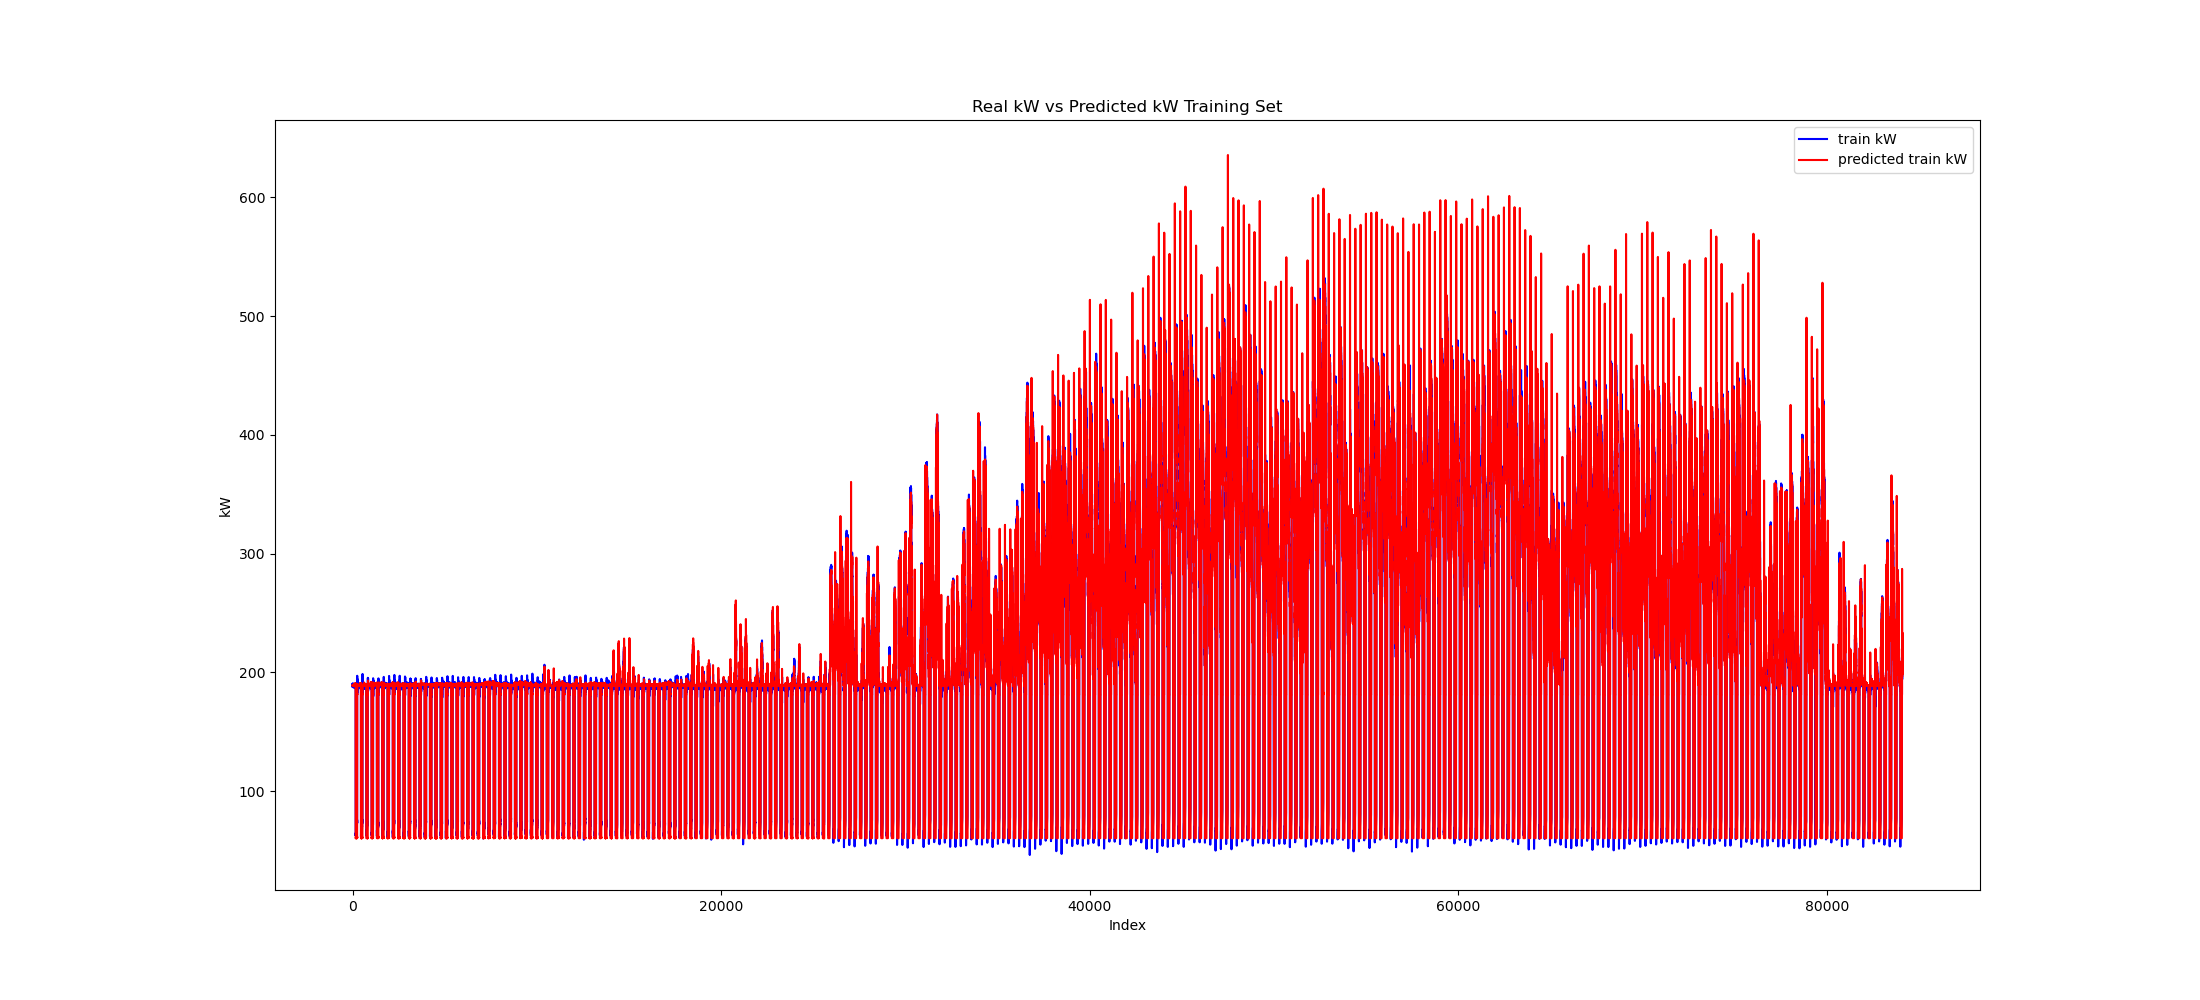

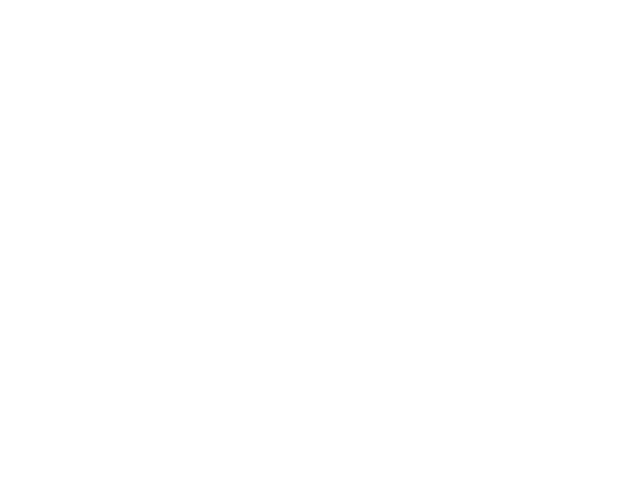

In [29]:
# import matplotlib.pyplot as plt2
plt.clf()
plt.figure(figsize=(22,10))

plt.plot(train_results['Train Predictions'], label="train kW", color="blue")
plt.plot(train_results['Actuals'], label="predicted train kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Training Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [30]:
r2_train = r2_score(train_results['Actuals'], train_results['Train Predictions'])
print("R-squared value of the training set:", r2_train)

trainMaeScore = mean_absolute_error(train_results['Actuals'], train_results['Train Predictions'])
print("MAE of the training set:", trainMaeScore)

trainMseScore = (mean_squared_error(train_results['Actuals'], train_results['Train Predictions']))
print("MSE of the training set:", trainMseScore)

R-squared value of the training set: 0.9746858810200205
MAE of the training set: 7.202934554935144
MSE of the training set: 369.3056140528313


In [31]:
val_predictions = model2.predict(X2_val)

y2_val_reshaped = y2_val.reshape(-1,1)

#inverse the scale to see the actual values
val_predictions_inverse = scaler.inverse_transform(val_predictions)
y2_val_reshaped = scaler.inverse_transform(y2_val_reshaped)

# flatten the arrays to plot properly
val_predictions_flattened = val_predictions_inverse.flatten()
y2_val_flattened = y2_val_reshaped.flatten()

val_results = pd.DataFrame(data={'Val Predictions':val_predictions_flattened, 'Actuals':y2_val_flattened})
val_results

329/329 [==============================] - 10s 27ms/step


,Val Predictions,Actuals
0,243.118652,244.061996
1,220.145065,214.155108
2,241.933609,249.388386
3,229.530487,229.071733
4,239.207489,233.923706
...,...,...
10507,190.103607,190.357430
10508,187.248978,190.866933
10509,189.599197,190.354333
10510,187.178970,190.864598


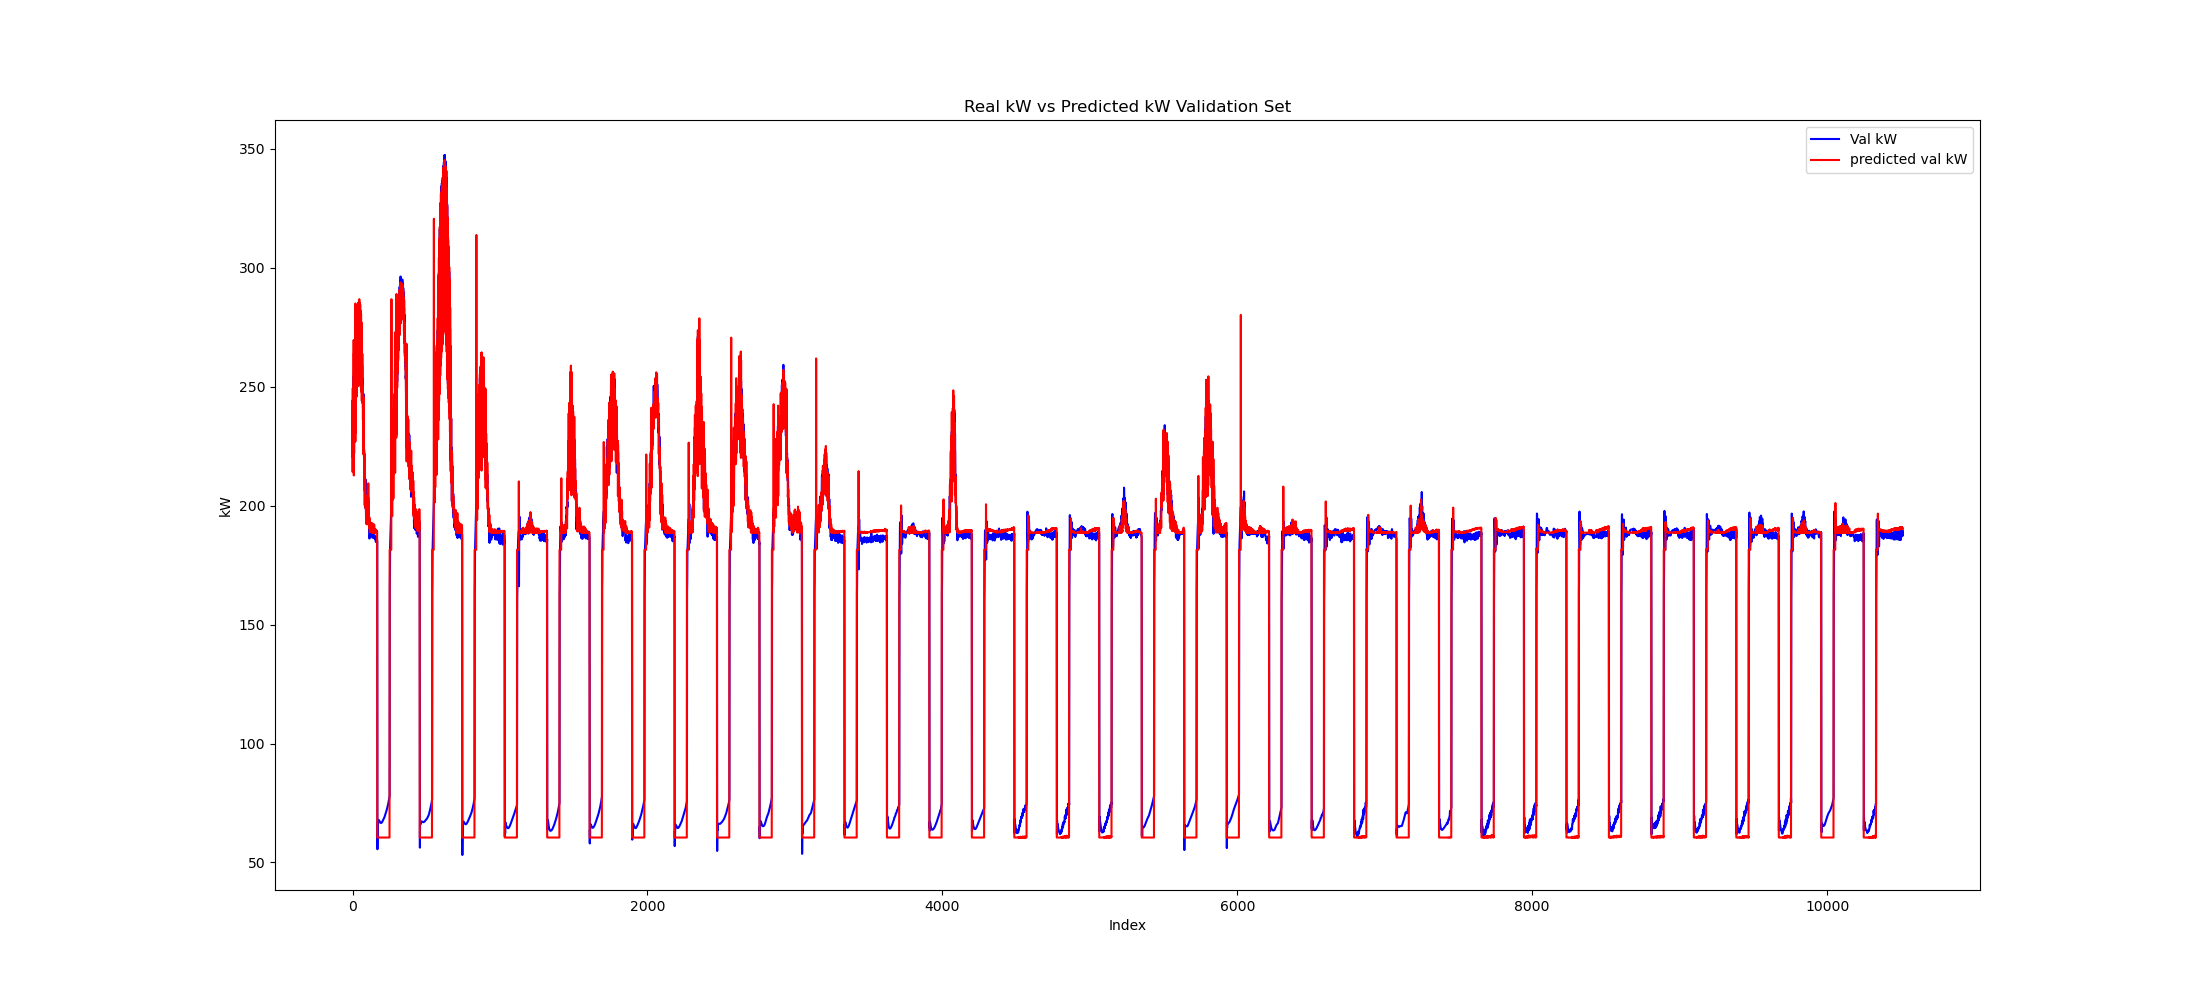

In [32]:
# import matplotlib.pyplot as plt2
# plt.clf()
plt.figure(figsize=(22,10))

plt.plot(val_results['Val Predictions'], label="Val kW", color="blue")
plt.plot(val_results['Actuals'], label="predicted val kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Validation Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [33]:
r2_val = r2_score(val_results['Actuals'], val_results['Val Predictions'])
print("R-squared value of the validation set:", r2_val)

valMaeScore = mean_absolute_error(val_results['Actuals'], val_results['Val Predictions'])
print("MAE of the validation set:", valMaeScore)

valMseScore = (mean_squared_error(val_results['Actuals'], val_results['Val Predictions']))
print("MSE of the validation set:", valMseScore)

R-squared value of the validation set: 0.9677797653369116
MAE of the validation set: 4.9888930894517225
MSE of the validation set: 131.13050120946582


In [34]:
test_predictions = model2.predict(X2_test)

y2_test_reshaped = y2_test.reshape(-1,1)

#inverse the scale to see the actual values
test_predictions_inverse = scaler.inverse_transform(test_predictions)
y2_test_reshaped = scaler.inverse_transform(y2_test_reshaped)

# flatten the arrays to plot properly
test_predictions_flattened = test_predictions_inverse.flatten()
y2_test_flattened = y2_test_reshaped.flatten()

test_results = pd.DataFrame(data={'Test Predictions':test_predictions_flattened, 'Actuals':y2_test_flattened})
test_results

324/324 [==============================] - 9s 27ms/step


,Test Predictions,Actuals
0,187.433853,190.886113
1,189.578949,190.385098
2,186.969559,190.908797
3,189.983215,190.432010
4,187.577438,190.915014
...,...,...
10363,187.965500,190.877238
10364,189.711166,191.321030
10365,188.090683,190.905346
10366,189.090805,191.417577


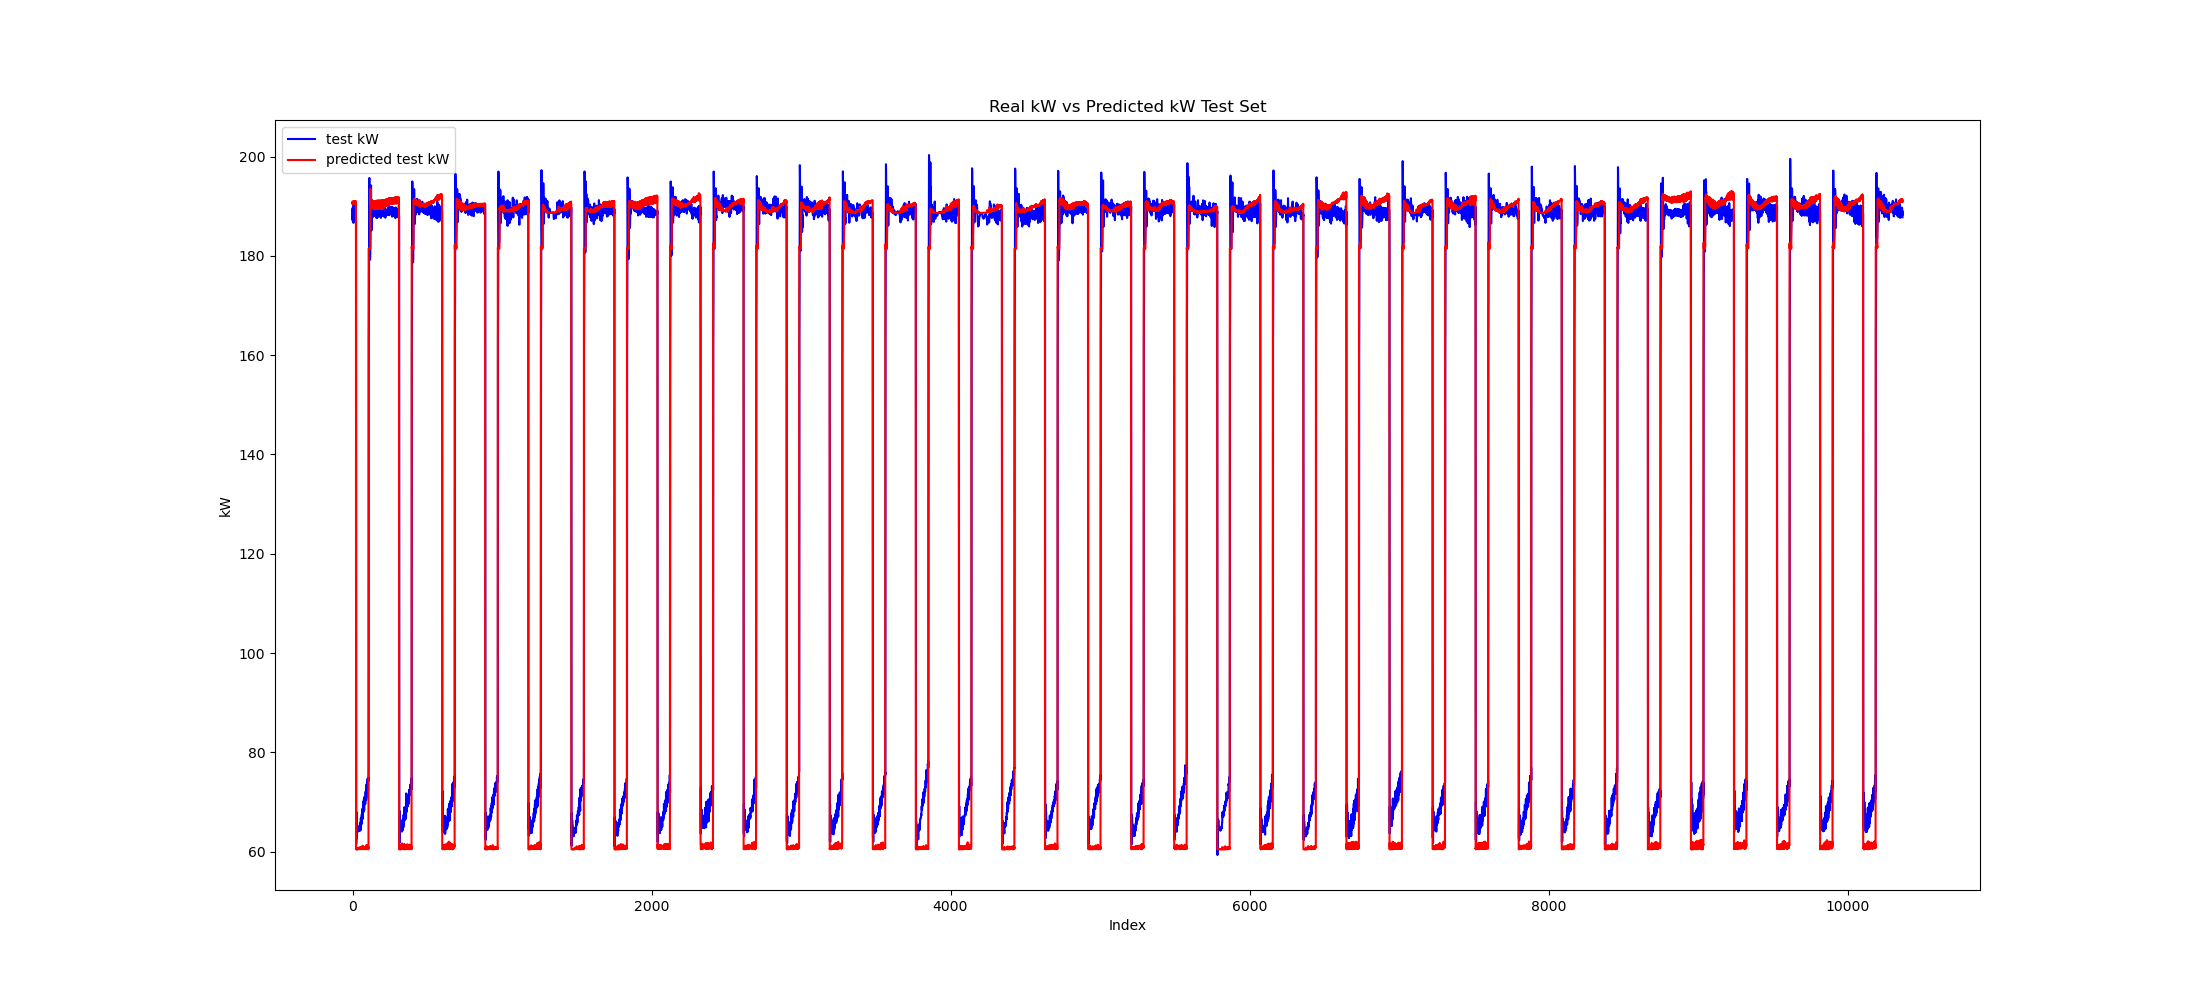

In [35]:
plt.figure(figsize=(22,10))

plt.plot(test_results['Test Predictions'], label="test kW", color="blue")
plt.plot(test_results['Actuals'], label="predicted test kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Test Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [36]:
r2_test = r2_score(test_results['Actuals'], test_results['Test Predictions'])
print("R-squared value of the test set:", r2_test)

testMaeScore = mean_absolute_error(test_results['Actuals'], test_results['Test Predictions'])
print("MAE of the test set:", testMaeScore)

testMseScore = (mean_squared_error(test_results['Actuals'], test_results['Test Predictions']))
print("MSE of the test set:", testMseScore)

R-squared value of the test set: 0.9643813283611304
MAE of the test set: 4.209131787465886
MSE of the test set: 122.08990636870992


In [37]:
# Save the model
model2.save('LSTM_Multivariate.keras')

In [38]:
train_results.rename(columns={'Train Predictions': 'Predictions'}, inplace=True)
val_results.rename(columns={'Val Predictions': 'Predictions'}, inplace=True)
test_results.rename(columns={'Test Predictions': 'Predictions'}, inplace=True)

combined_data = np.concatenate((train_results, val_results, test_results), axis=0)

column_names = ['Predictions', 'Actuals']

combined_data_df = pd.DataFrame(combined_data, columns=column_names) 

display(combined_data_df)

combined_data_df.to_csv('LSTM_Multivariate_predictions.csv', index=True)

,Predictions,Actuals
0,189.855362,189.191060
1,188.573334,189.005978
2,188.083511,189.018581
3,188.044006,189.049593
4,188.939728,189.106996
...,...,...
104971,187.965500,190.877238
104972,189.711166,191.321030
104973,188.090683,190.905346
104974,189.090805,191.417577
